In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

import sys
sys.path.append("../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import bisect
from tqdm import tqdm
from ipywidgets import interact
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from scipy import signal

from src.fmcw_simulation.simulation import FmcwRadar
from src.py_network.adaptive_resonate import AdaptiveResonate

plt.rc('xtick',labelsize=25)
plt.rc('ytick',labelsize=25)
# mpl.rcParams['figure.dpi'] = 200 
mpl.rcParams['figure.figsize'] = (12, 9) 
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['axes.labelsize'] = 25
mpl.rcParams['legend.fontsize'] = 20
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#003052", "#C71818", "#18C7C7", "#70C718", "#7018C7"])
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39"])

In [2]:
radar_config = {
    "n_rx": 1,
    "fb" : 77e9,
    "B" : 1.5e9,
    "n_chirps": 64,
    "n_samples": 128,
    "t_chirp": 40e-6,
    "IQ": True,
    "noise_std": 0.0001
}
# radar_config = {
#     "n_rx": 1,
#     "fb" : 76e9,
#     "B" : 500e6,
#     "n_chirps": 64,
#     "n_samples": 256,
#     "t_chirp": 50e-6,
#     "IQ": True,
#     "noise_std": 0.000001
# }
fmcw = FmcwRadar(radar_config)

In [3]:
fmcw = FmcwRadar(config=radar_config)
targets = [
    {
        "range":0.7,
        "velocity": 0.0,
        "angle": np.deg2rad(0)
    },
    # {
    #     "range":6.0,
    #     "velocity": 0,
    #     "angle": np.deg2rad(0)
    # },
    # {
    #     "range": 6.0,
    #     "velocity": 6,
    #     "angle": np.deg2rad(20)
    # },
    # {
    #     "range": 1.8,
    #     "velocity": 0,
    #     "angle": np.deg2rad(40)
    # }
]

fmcw.set_targets(targets)
frame = fmcw.generate_data_snr()

In [4]:
fmcw.snr

np.float64(79.21935797540509)

Text(0.5, 0, 'samples')

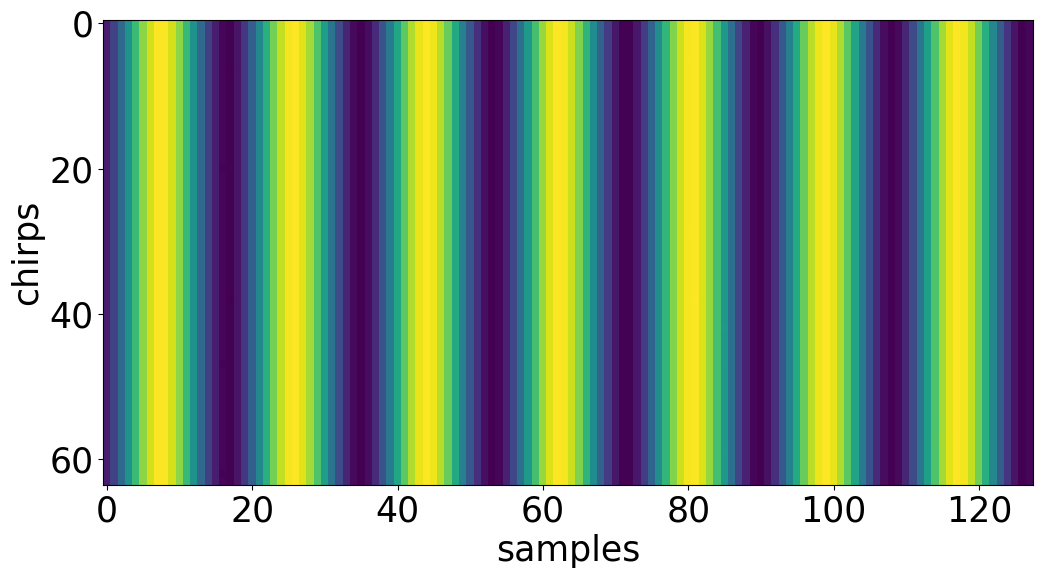

In [5]:
plt.imshow(frame[0].real, interpolation='none')
plt.ylabel("chirps")
plt.xlabel("samples")

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


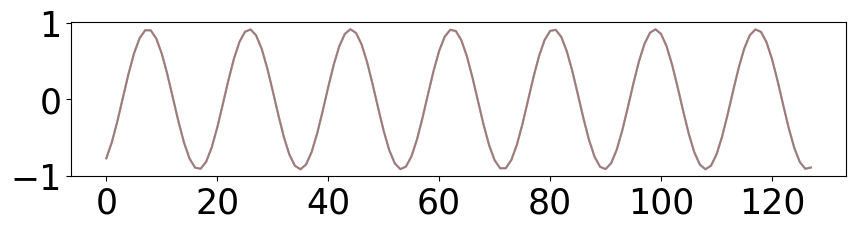

In [6]:
plt.figure(figsize=(10, 2))
plt.plot(fmcw.pure_signal[0, 0, :].flatten())
plt.plot(frame[0, 0, :], alpha=0.5)
# plt.plot(frame[0, 1, :].flatten())

In [7]:
ranges = fmcw.get_ranges()
vels = fmcw.get_velocities()
angles = fmcw.get_angles()

In [8]:
ranges

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3])

In [9]:
n_units = len(targets)
t_max = fmcw.t_chirp * fmcw.n_chirps
res_net = AdaptiveResonate(
            n_units, 
            t_max, 
            fmcw.t_chirp / fmcw.n_samples, 
            k=1,
            feedback=True,
            w_scale= np.ones((fmcw.n_rx, n_units))*40e-6*10,
            n_rxs=fmcw.n_rx
)

# res_net.spike_condition = res_net.period_spiking
res_net.normalize_input = False
res_net.normalize_neuron = True

min_starting_freq = 2
max_starting_freq = 30

for rx in range(fmcw.n_rx):
    res_net.ws[rx] = ((np.linspace(20, 20.1, res_net.nfreq) + rx*5) * 2 * np.pi) / fmcw.t_chirp
    # starting_freqs = np.random.rand(res_net.nfreq) * (max_starting_freq - min_starting_freq) + min_starting_freq
    # res_net.ws[rx] = (starting_freqs * 2 * np.pi) / fmcw.t_chirp
    
res_net.periods = ((2 * np.pi) / (res_net.ws * res_net.t_res)).astype(int)
# res_net.enable_rx_lock()

# for i in range(res_net.total_neurons):
#         res_net.ws_locking_matrix[i*n_units:(i+1)*n_units, i*n_units:(i+1)*n_units] = 1

In [10]:
# res_net.ws[:] = fmcw.get_freq_from_range(targets[0]['range']) * 2 * np.pi

In [11]:
fmcw = FmcwRadar(config=radar_config)
fmcw.set_targets(targets)
frame = fmcw.generate_data()

In [12]:
frames_to_use = 1
ws_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units))
w_dot_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units), dtype=complex)
vs_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units), dtype=complex)
spikes_out = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units))
flat_frame = frame.reshape((frame.shape[0], -1))
# input_w_feedback = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx))
gt_ranges = []

for f in tqdm(range(frames_to_use)):
    
    frame = fmcw.generate_data()
    # frame = fmcw.apply_hann(frame)
    flat_frame = frame.reshape((frame.shape[0], -1))

    # for i in range(flat_frame.shape[-1]):
    #     ws_hist[i+f*res_net.n_steps] = res_net.ws
    #     vs_hist[i+f*res_net.n_steps] = res_net.vs
    #     # input_w_feedback[i+f*res_net.n_steps] = res_net.neuron_input
    #     w_dot_hist[i+f*res_net.n_steps] = res_net.w_dot

    #     spikes = res_net.update_neurons(np.copy(flat_frame[:, i]))
    #     spikes_out[i + f*res_net.n_steps] = spikes
    #     gt_ranges.append(fmcw.targets_info[0]['range'])
    vs_hist, ws_hist = res_net.update_neurons_frame(flat_frame, intermediate=True)

    # for t in fmcw.targets_info:
    #     t['range'] += t['velocity'] * fmcw.t_chirp * fmcw.n_chirps
    # print(fmcw.targets_info[0]['range'])

gt_ranges = np.array(gt_ranges)

  0%|          | 0/1 [00:00<?, ?it/s]

/home/chistefano/code/tue/frequency_adaptive_clean/notebooks/../src/py_network/adaptive_resonate.py:74: RuntimeWarning: invalid value encountered in scalar divide
  vs_val = self.vs[0, k] / np.abs(self.vs[0, k])
100%|██████████| 1/1 [00:00<00:00,  6.30it/s]


In [13]:
fmcw.targets_info

[{'range': 0.7,
  'velocity': 0.0,
  'angle': np.float64(0.0),
  'A_rand': 2.2960356957291537,
  'p_rand': 0.28980522964376504}]

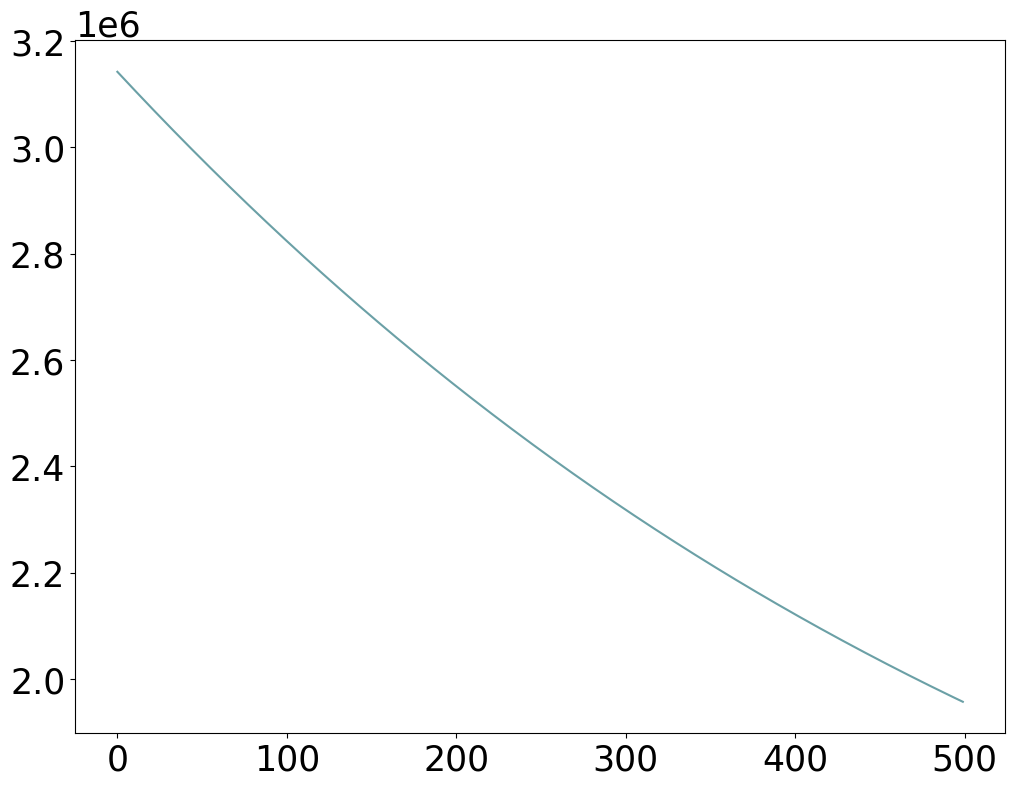

In [14]:
plt.plot(ws_hist.squeeze()[:500])


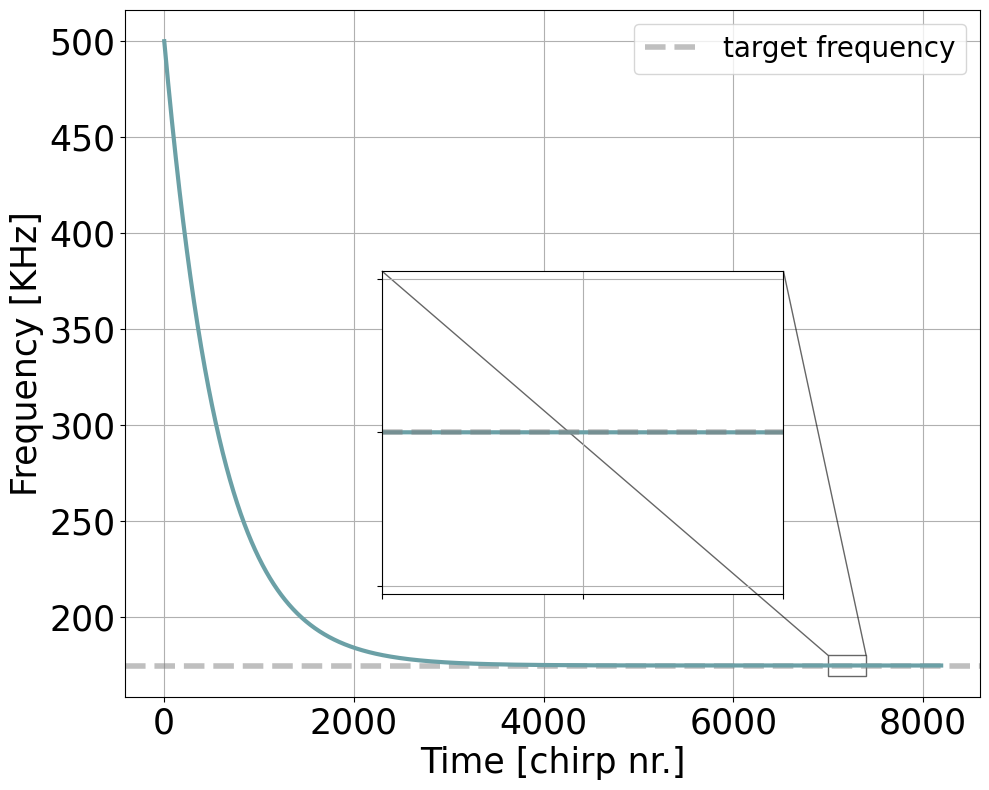

In [15]:
fig, axs = plt.subplots(1, figsize=(10, 8))

a = 0
gt_lwidth = 1.3
lwidth = 3.0
factor = 1e3

ax = axs

# plot the ground truth frequencies
for t in targets:
    f = (t['range'] * 2 * fmcw.B) / (FmcwRadar.c * fmcw.t_chirp * factor) 
    ax.axhline(f, c="grey", label="target frequency", linestyle="--", alpha=0.5, linewidth=4)

# plot the history of oscillator frequency
ax.plot(ws_hist[a:, :, :].squeeze() / (2 * np.pi) / factor, linewidth=lwidth,
        linestyle="solid")
# ax.plot(ws_hist[a:, 1, 0].squeeze() / (2 * np.pi) / factor, linewidth=lwidth,
#         linestyle="dotted")
# ax.plot(ws_hist[a:, 2, 0].squeeze() / (2 * np.pi) / factor, linewidth=lwidth,
#         linestyle="dashed")

osc_frequency_normalized = (ws_hist / (2 * np.pi * factor))[:, :, 0]
# ax.set_ylim([osc_frequency_normalized.min() * 0.95, osc_frequency_normalized.max() * 1.05])


ax.legend()
ax.set_xlabel("Time [chirp nr.]")
ax.set_ylabel("Frequency [KHz]")
# ax.set_title("Adaptive Oscillators Dynamics")

ax.grid()

ytop = osc_frequency_normalized[-1].max() * 1.03
ybot = osc_frequency_normalized[-1].max() * 0.97

inset_chirp_start = int(7000)
inset_chirp_end = int(7400)
xleft = inset_chirp_start
xright = inset_chirp_end

axins = ax.inset_axes(
    [0.3, 0.15, 0.47, 0.47],
    xlim=(xleft, xright), ylim=(ybot, ytop), xticklabels=[], yticklabels=[])

mark_inset(ax, axins, loc1=1, loc2=2, alpha=0.6)
axins.plot(osc_frequency_normalized[:, :], linewidth=lwidth, linestyle="solid")
for t in targets:
    f = (t['range'] * 2 * fmcw.B) / (FmcwRadar.c * fmcw.t_chirp * factor) 
    axins.axhline(f, c="grey", label="target frequency", linestyle="--", alpha=0.5, linewidth=4)
axins.grid()

plt.tight_layout()

plt.savefig("paper_figures/two_oscillators_detail_hann.pdf")

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


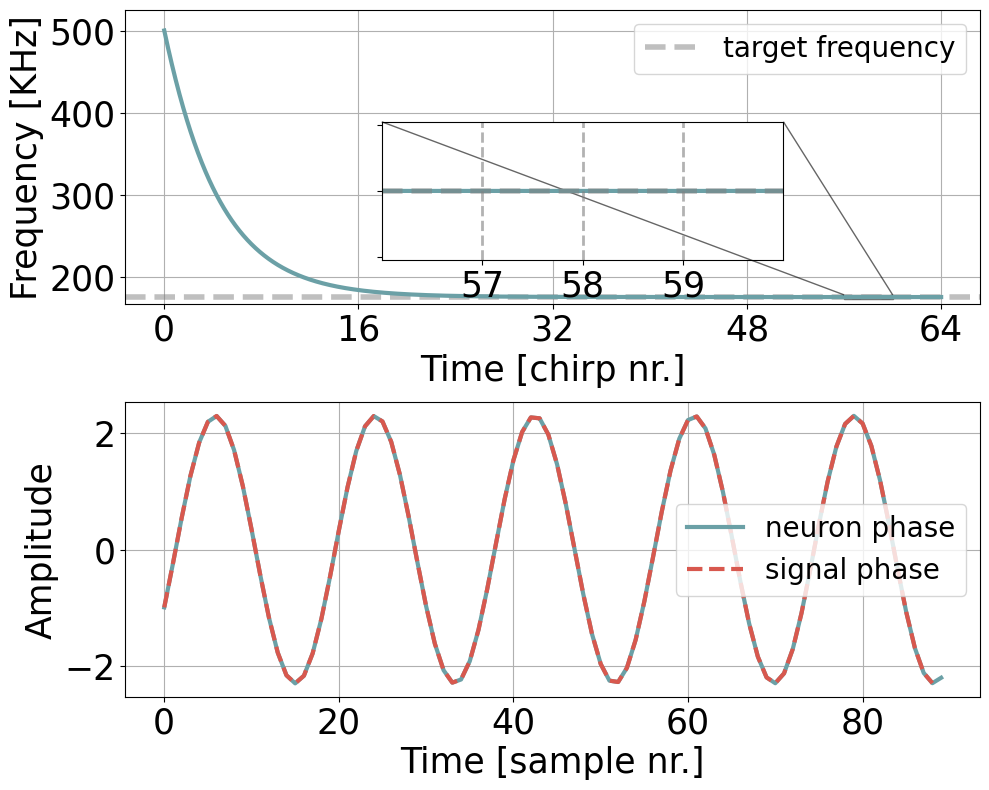

In [16]:
fig, axs = plt.subplots(2, figsize=(10, 8))

a = 0
gt_lwidth = 1.3
lwidth = 3.0
factor = 1e3

ax = axs[0]

# plot the ground truth frequencies
for t in targets:
    f = (t['range'] * 2 * fmcw.B) / (FmcwRadar.c * fmcw.t_chirp * factor) 
    ax.axhline(f, c="grey", label="target frequency", linestyle="--", alpha=0.5, linewidth=4)

# plot the history of oscillator frequency
ax.plot(ws_hist[a:, :, :].squeeze() / (2 * np.pi) / factor, linewidth=lwidth,
        linestyle="solid")
# ax.plot(ws_hist[a:, 1, 0].squeeze() / (2 * np.pi) / factor, linewidth=lwidth,
#         linestyle="dotted")
# ax.plot(ws_hist[a:, 2, 0].squeeze() / (2 * np.pi) / factor, linewidth=lwidth,
#         linestyle="dashed")

osc_frequency_normalized = (ws_hist / (2 * np.pi * factor))[:, :, 0]

ax.set_ylim([osc_frequency_normalized.min() * 0.95, osc_frequency_normalized.max() * 1.05])

ytop = osc_frequency_normalized[-1].max() * 1.015
ybot = osc_frequency_normalized[-1].max() * 0.985

inset_chirp_start = int(fmcw.n_chirps * 0.875)
inset_chirp_end = int(fmcw.n_chirps * 0.95)
xleft = inset_chirp_start * fmcw.n_samples
xright = inset_chirp_end * fmcw.n_samples

axins = ax.inset_axes(
    [0.3, 0.15, 0.47, 0.47],
    xlim=(xleft, xright), ylim=(ybot, ytop), xticklabels=[], yticklabels=[])

axins.plot(osc_frequency_normalized[:, :], linewidth=lwidth, linestyle="solid")
# axins.plot(osc_frequency_normalized[:, 1], linewidth=lwidth, linestyle="dotted")
# axins.plot(osc_frequency_normalized[:, 2], linewidth=lwidth, linestyle="dashed")

axins.axhline(f, c="grey", label="target frequency", linestyle="--", alpha=0.5, linewidth=4)
axins.set_xticks(np.arange(inset_chirp_start, inset_chirp_end)[1:]*fmcw.n_samples,
                 np.arange(inset_chirp_start, inset_chirp_end)[1:])
for i in np.arange(inset_chirp_start, inset_chirp_end)[1:]:
    axins.axvline(i*fmcw.n_samples, c="grey", linestyle="--", alpha=0.6, linewidth=2)
# ax.indicate_inset_zoom(axins, edgecolor="black")
mark_inset(ax, axins, loc1=1, loc2=2, alpha=0.6)

ax.legend()
ax.set_xlabel("Time [chirp nr.]")
ax.set_ylabel("Frequency [KHz]")
# ax.set_title("Adaptive Oscillators Dynamics")

chirp_ticks_vals = [0, 16, 32, 48, 64]
locs = [val * fmcw.n_samples for val in chirp_ticks_vals]
ax.set_xticks(locs, chirp_ticks_vals)
ax.grid()

# phase plot
ax2 = axs[1]
ax2.plot(vs_hist[-int(1.2*fmcw.n_samples*2):-int(0.5*fmcw.n_samples*2):2, :, 0],
         linewidth=lwidth, label="neuron phase")
ax2.plot(flat_frame[0, -int(1.2*fmcw.n_samples):-int(0.5*fmcw.n_samples)],
         linewidth=lwidth, label="signal phase", linestyle="dashed")
ax2.set_ylabel("Amplitude")
ax2.set_xlabel("Time [sample nr.]")
ax2.grid()
ax2.legend()

# ax.set_title("Convergence with Hann w.")

plt.tight_layout()

plt.savefig("paper_figures/single_oscillator_detail_hann.pdf")

In [17]:
fmcw.get_range_from_freq(res_net.ws / (2 * np.pi))

array([[0.70000074]])

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


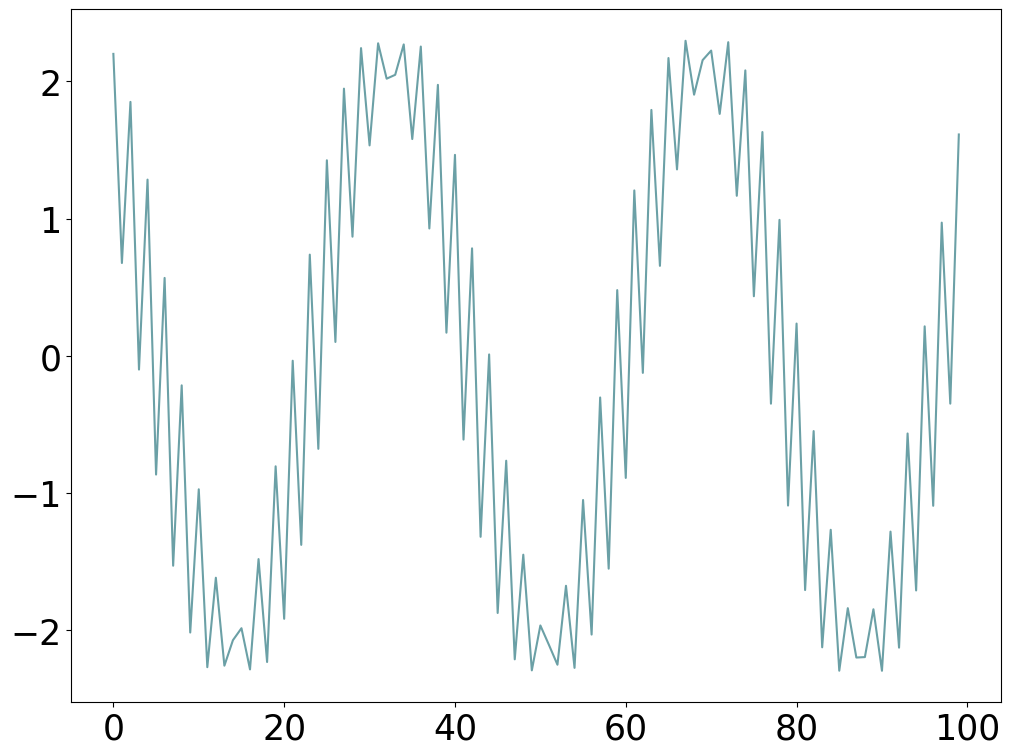

In [18]:
plt.plot(vs_hist[:100].squeeze())

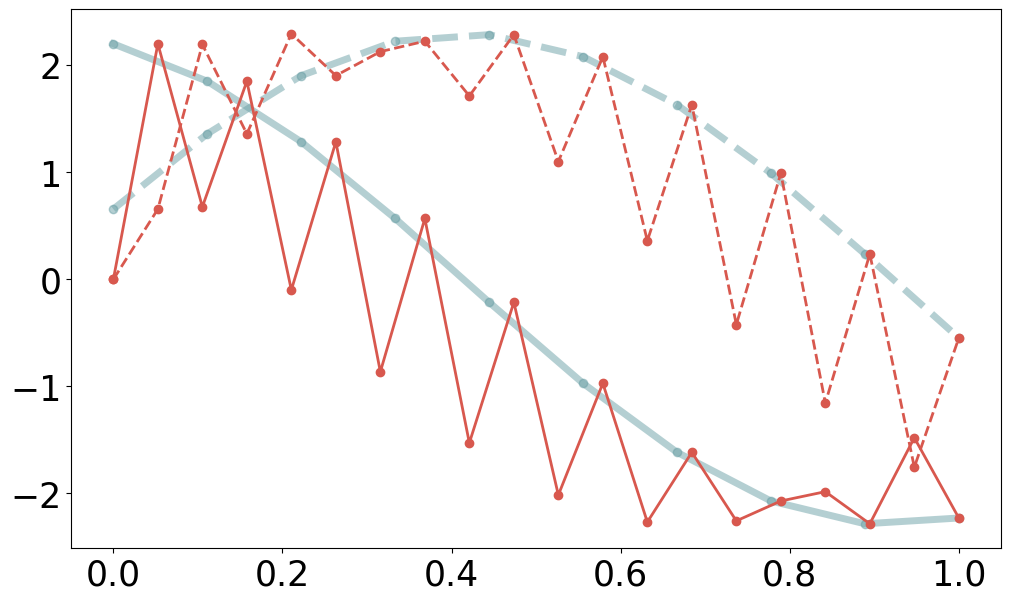

In [19]:
base = 0 #vs_hist.shape[0] // 2 - 200
ww = 10

vs_ext = np.zeros((vs_hist.shape[0]+1), dtype=complex)
vs_ext[1:] = vs_hist[:, 0, 0].squeeze()

fig, ax = plt.subplots(1, figsize=(12, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww*2)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=5, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=5, c="C0", linestyle="--", marker="o")

ax.plot(x_vs, np.real(vs_ext[base*2:base*2+ww*2]), linewidth=2, c="C1", label="osc. signal", marker="o")
ax.plot(x_vs, np.imag(vs_ext[base*2:base*2+ww*2]), linewidth=2, c="C1", linestyle="--", marker="o")

# ax.legend(loc="lower right")

# plt.savefig("figures/resonate_detail_feedback_end_neg.pdf")

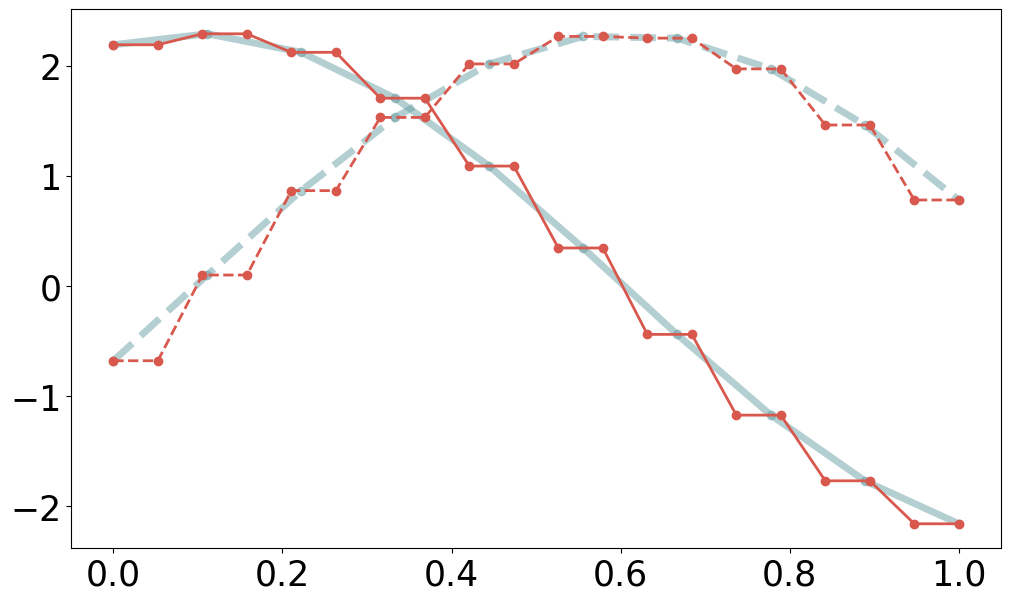

In [20]:
base = vs_hist.shape[0] // 2 - 20
ww = 10

vs_ext = np.zeros((vs_hist.shape[0]+1), dtype=complex)
vs_ext[1:] = vs_hist[:, 0, 0].squeeze()

fig, ax = plt.subplots(1, figsize=(12, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww*2)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=5, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=5, c="C0", linestyle="--", marker="o")

ax.plot(x_vs, np.real(vs_ext[base*2:base*2+ww*2]), linewidth=2, c="C1", label="osc. signal", marker="o")
ax.plot(x_vs, np.imag(vs_ext[base*2:base*2+ww*2]), linewidth=2, c="C1", linestyle="--", marker="o")

# ax.legend(loc="lower right")

# plt.savefig("figures/resonate_detail_feedback_end_neg.pdf")

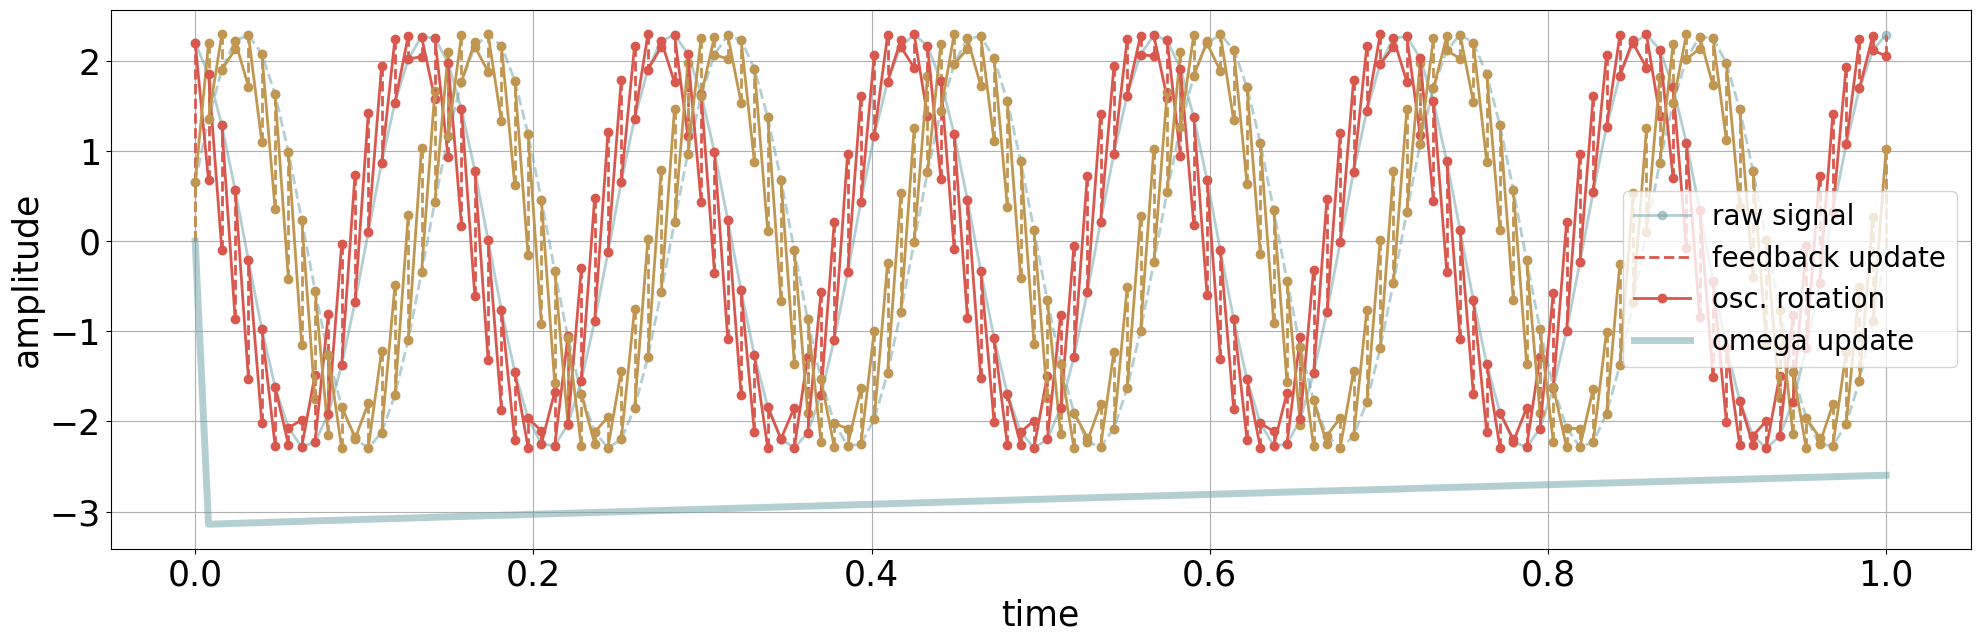

In [21]:
base = 0 #vs_hist.shape[0] // 2 - 200
ww = 128

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(24, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=2, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=2, c="C0", linestyle="--", marker="o")

i=0
ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--", label="feedback update")
ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o", label="osc. rotation")
ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--")
        ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

    if i+1 < x_vs.size:
        ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o")
        ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="omega update")

ax.set_xlabel("time")
ax.set_ylabel("amplitude")
ax.legend()
ax.grid()

plt.savefig("paper_figures/raf_explaination_big_start.pdf")

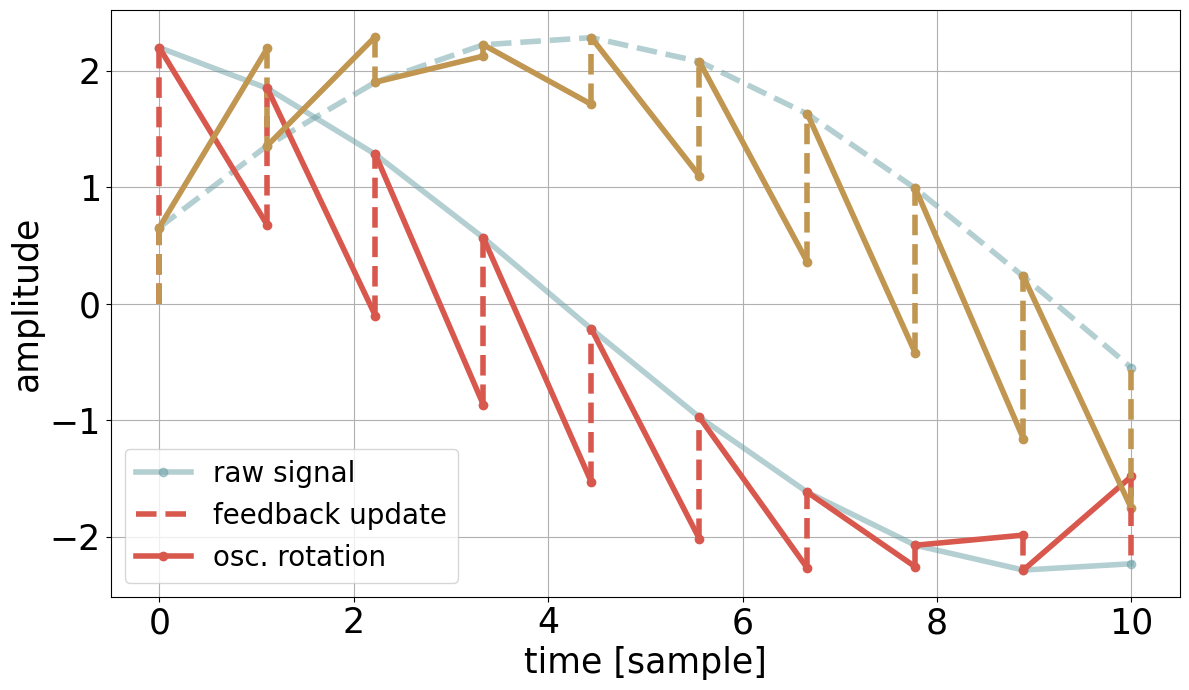

In [22]:
base = 0 #fmcw.n_samples -10 #vs_hist.shape[0] // 2 - 200
ww = 10

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(12, 7))

x_frame = np.linspace(0, 1, ww) * ww
x_vs = np.linspace(0, 1, ww) * ww

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=4, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=4, c="C0", linestyle="--", marker="o")

i=0
ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=4, linestyle="--", label="feedback update")
ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=4, linestyle="--")

ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=4, marker="o", label="osc. rotation")
ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=4, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=4, linestyle="--")
        ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=4, linestyle="--")

    if i+1 < x_vs.size:
        ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=4, marker="o")
        ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=4, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
# ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="$\omega$ update")

ax.set_xlabel("time [sample]")
ax.set_ylabel("amplitude")
ax.legend()
ax.grid()

plt.tight_layout()
plt.savefig("paper_figures/raf_explaination_small_start.pdf", bbox_inches="tight")

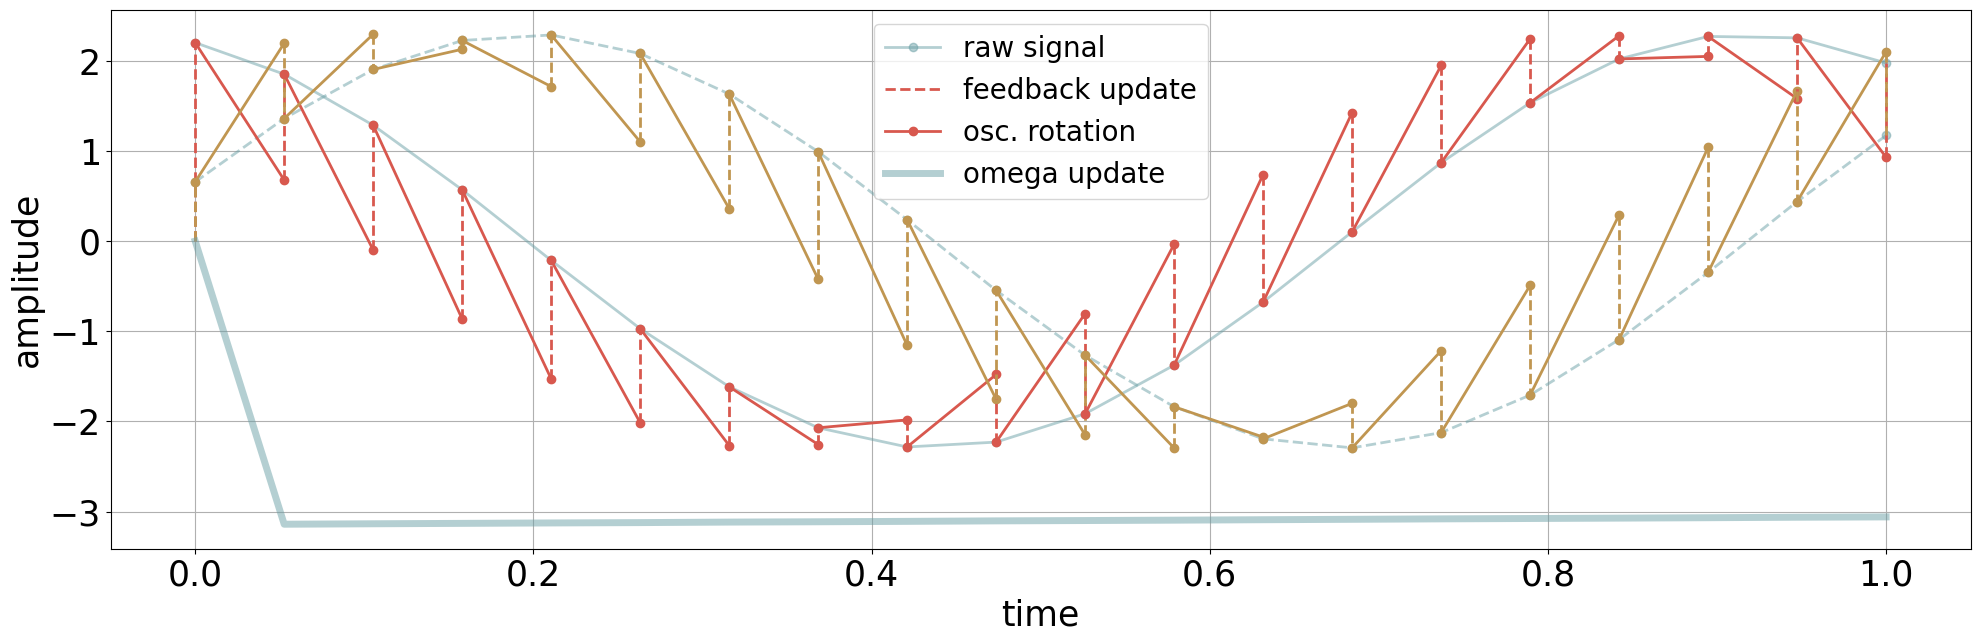

In [23]:
base = 0 #vs_hist.shape[0] // 2 - 200
ww = 20

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(24, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=2, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=2, c="C0", linestyle="--", marker="o")

i=0
ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--", label="feedback update")
ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o", label="osc. rotation")
ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--")
        ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

    if i+1 < x_vs.size:
        ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o")
        ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="omega update")

# ax.fill_between(x_frame, -1, 1, 
#                 where=np.real(flat_frame.squeeze())[base:base+ww] > 0.0 & (s > 0.75), alpha=0.5)

ax.set_xlabel("time")
ax.set_ylabel("amplitude")
ax.legend()
ax.grid()

plt.savefig("paper_figures/raf_explaination_tiny_start.pdf")

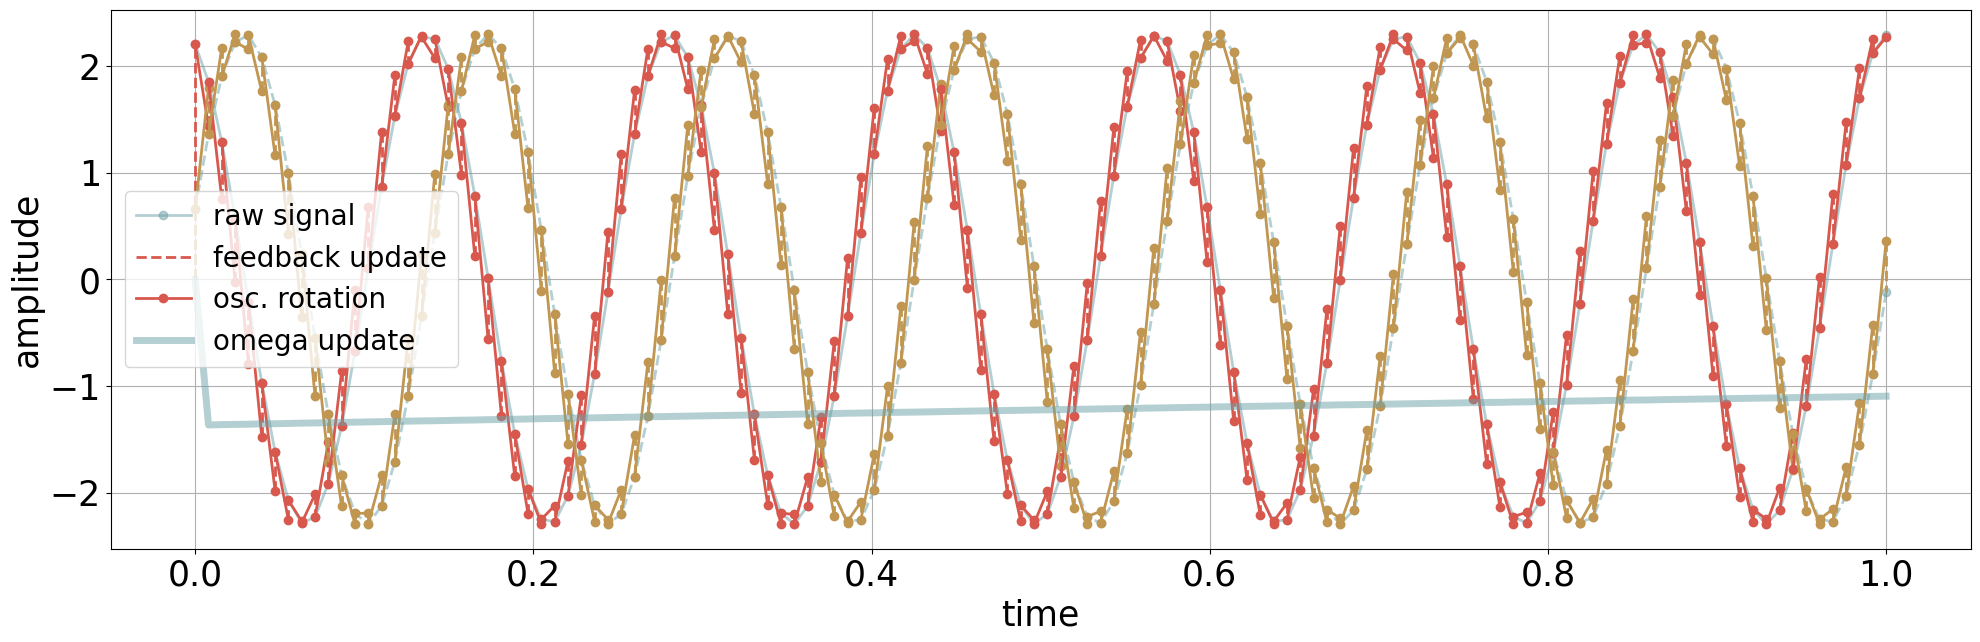

In [24]:
base = 128*4 #vs_hist.shape[0] // 2 - 200
ww = 128*1

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(24, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=2, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=2, c="C0", linestyle="--", marker="o")

i=0
ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--", label="feedback update")
ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o", label="osc. rotation")
ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--")
        ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

    if i+1 < x_vs.size:
        ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o")
        ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="omega update")

ax.set_xlabel("time")
ax.set_ylabel("amplitude")
ax.legend()
ax.grid()

plt.savefig("paper_figures/raf_explaination_big_mid.pdf")

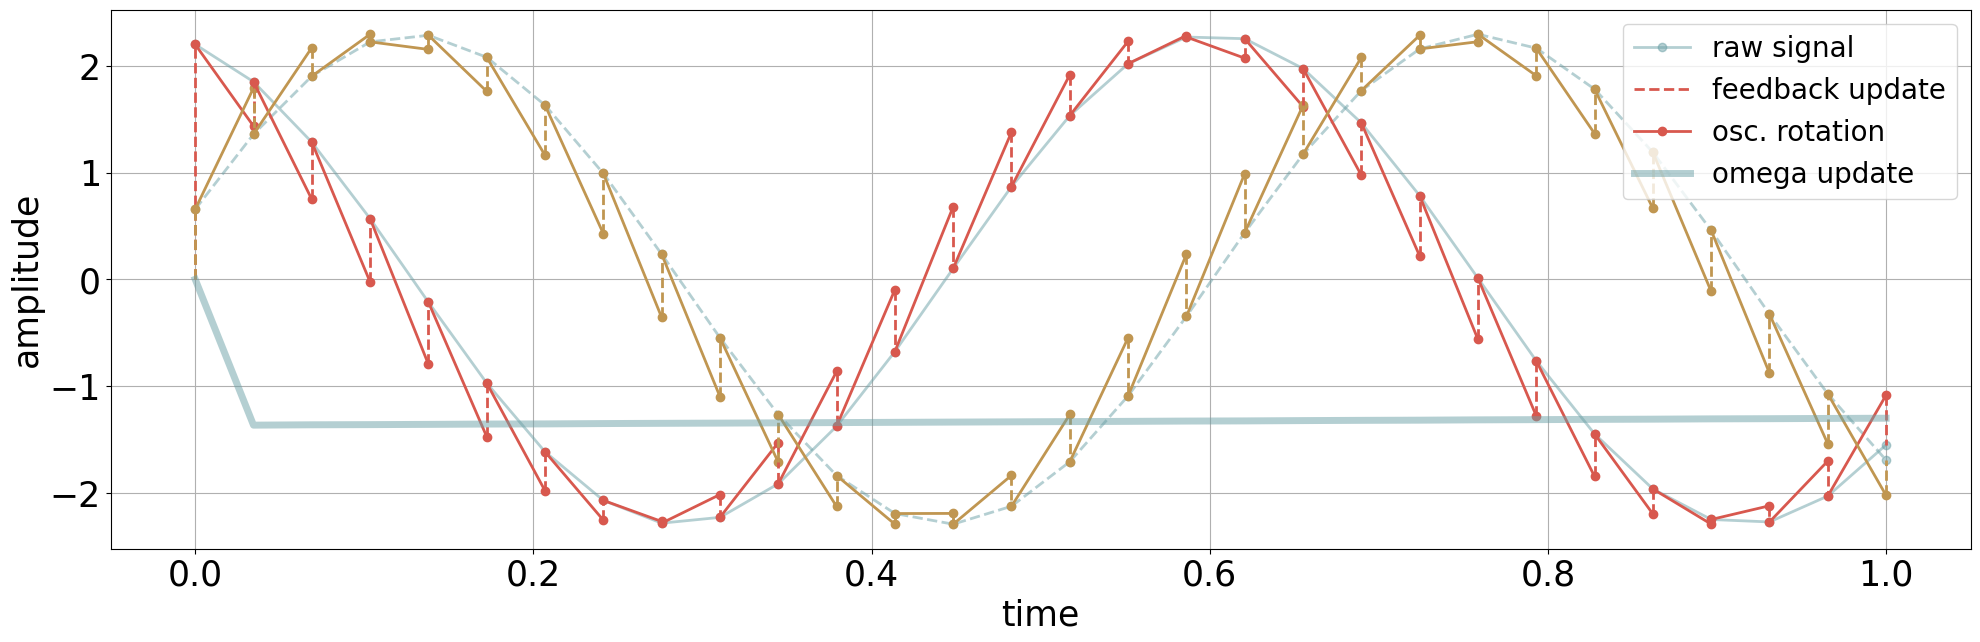

In [25]:
base = 128*4 #vs_hist.shape[0] // 2 - 200
ww = 30

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(24, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=2, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=2, c="C0", linestyle="--", marker="o")

i=0
ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--", label="feedback update")
ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o", label="osc. rotation")
ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        ax.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--")
        ax.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

    if i+1 < x_vs.size:
        ax.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o")
        ax.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="omega update")

ax.set_xlabel("time")
ax.set_ylabel("amplitude")
ax.legend()
ax.grid()

plt.savefig("paper_figures/raf_explaination_small_mid.pdf")

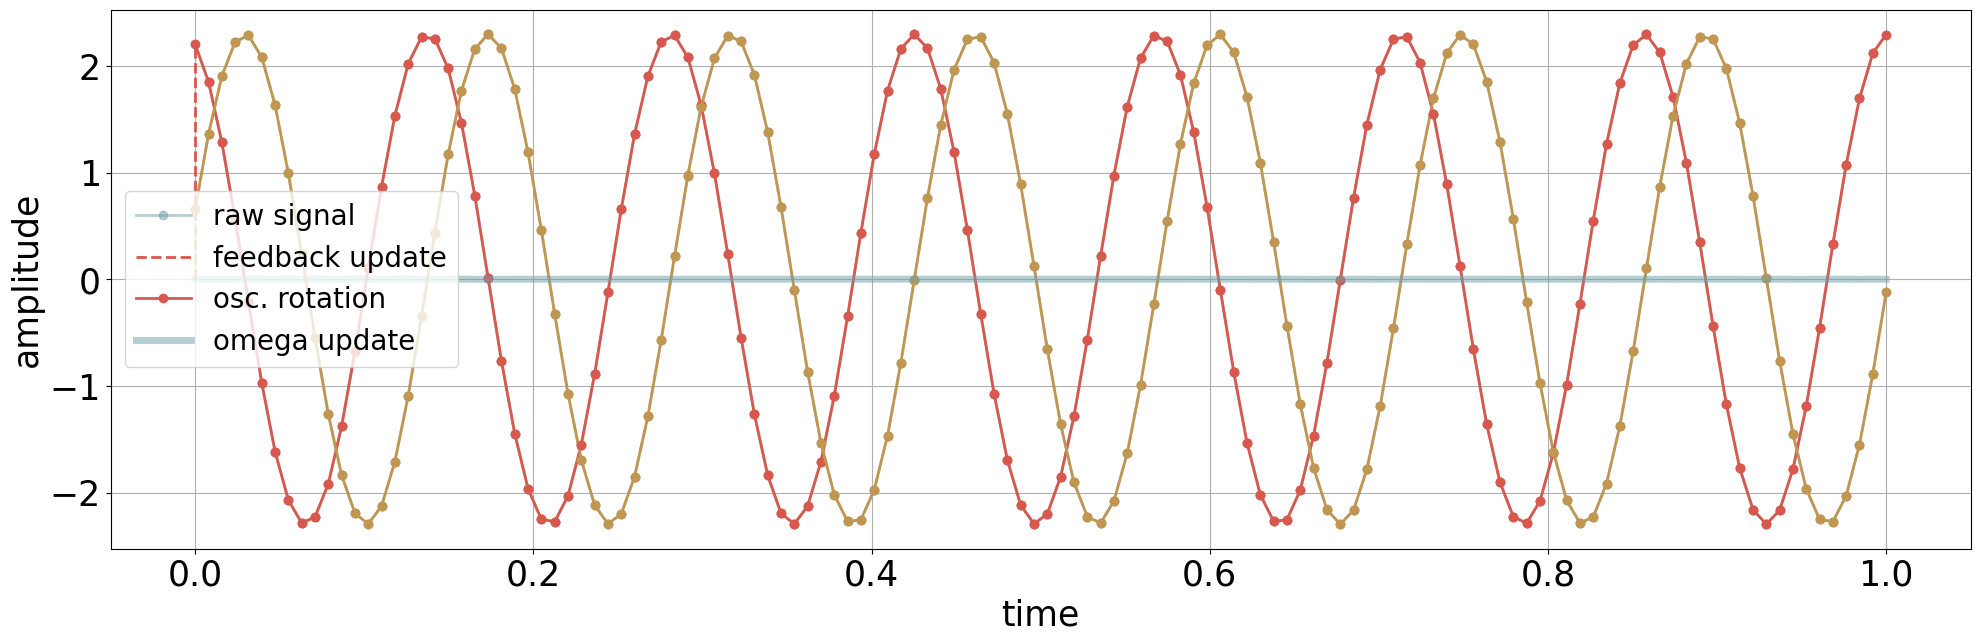

In [26]:
base = vs_hist.shape[0] // 2 - 128*2
ww = 128

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(24, 7))

x_frame = np.linspace(0, 1, ww)
x_vs = np.linspace(0, 1, ww)

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=2, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=2, c="C0", linestyle="--", marker="o")

i=0
plt.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--", label="feedback update")
plt.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

plt.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o", label="osc. rotation")
plt.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        plt.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=2, linestyle="--")
        plt.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=2, linestyle="--")

    if i+1 < x_vs.size:
        plt.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=2, marker="o")
        plt.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=2, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="omega update")

ax.set_xlabel("time")
ax.set_ylabel("amplitude")
ax.legend()
ax2.legend(loc=0)
ax.grid()

plt.savefig("paper_figures/raf_explaination_big_end.pdf")

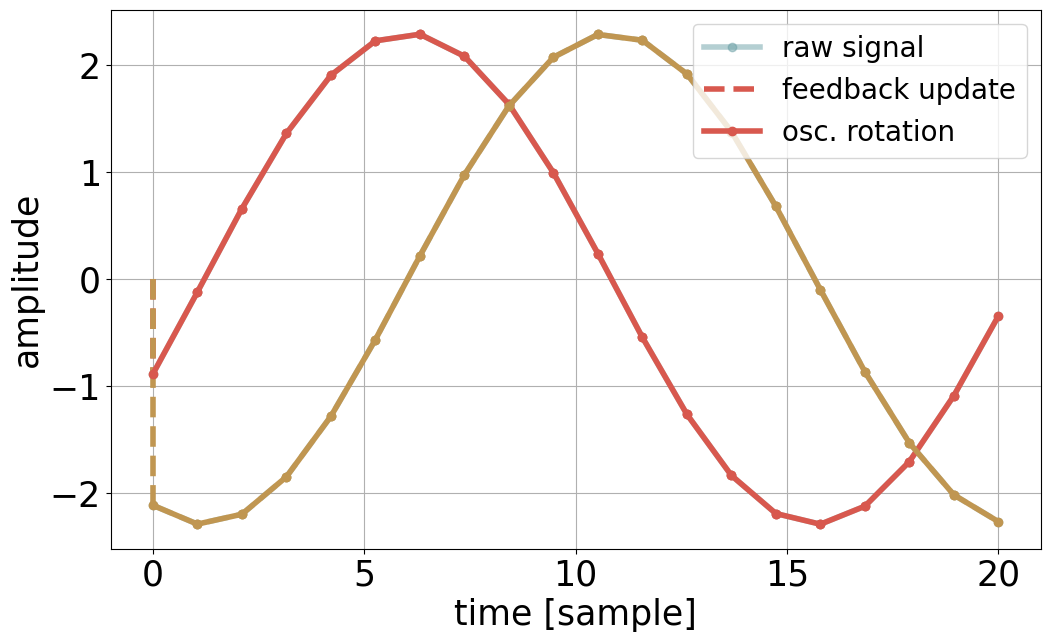

In [27]:
base = vs_hist.shape[0] // 2 - 128*2 + 30
ww = 20

vs_1 = np.zeros((ww*2+1), dtype=complex)
vs_sum = np.zeros((ww*2+1), dtype=complex)
vs_1[1:] = vs_hist[base*2:base*2+ww*2, 0, 0].squeeze()
vs_sum[1:] = vs_hist[base*2:base*2+ww*2, 0, :].sum(axis=-1).squeeze()

fig, ax = plt.subplots(1, figsize=(12, 7))

x_frame = np.linspace(0, 1, ww) * ww
x_vs = np.linspace(0, 1, ww) * ww

ax.plot(x_frame, np.real(flat_frame.squeeze())[base:base+ww], alpha=0.5, label="raw signal", linewidth=4, c="C0", marker="o")
ax.plot(x_frame, np.imag(flat_frame.squeeze())[base:base+ww], alpha=0.5, linewidth=4, c="C0", linestyle="--", marker="o")

i=0
plt.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=4, linestyle="--", label="feedback update")
plt.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=4, linestyle="--")

plt.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=4, marker="o", label="osc. rotation")
plt.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=4, marker="o")

for i in np.arange(1, x_vs.size):
    if i > 0:
        plt.plot([x_vs[i], x_vs[i]], np.real(vs_1[i*2:i*2+2]), c="C1", linewidth=4, linestyle="--")
        plt.plot([x_vs[i], x_vs[i]], np.imag(vs_1[i*2:i*2+2]), c="C2", linewidth=4, linestyle="--")

    if i+1 < x_vs.size:
        plt.plot(x_vs[i: i+2], np.real(vs_1[i*2+1:i*2+3]), c="C1", linestyle="-", linewidth=4, marker="o")
        plt.plot(x_vs[i: i+2], np.imag(vs_1[i*2+1:i*2+3]), c="C2", linestyle="-", linewidth=4, marker="o")

w_dot = vs_1[:-1:2].imag * (flat_frame.squeeze()[base:base+ww].real)
w_dot -= vs_1[:-1:2].real * (flat_frame.squeeze()[base:base+ww].imag)
# ax.plot(x_frame, -w_dot, linewidth=5, alpha=0.5, label="$\omega$ update")

ax.set_xlabel("time [sample]")
ax.set_ylabel("amplitude")
ax.legend()
ax.grid()

plt.savefig("paper_figures/raf_explaination_small_end.pdf", bbox_inches="tight")